# HDB Resale Price Regression — Notebook 2: Explore Distributions

EDA on the 2-year regression dataset (50,718 transactions, May 2024 to April 2026). Checking distributions, relationships between variables, and anything that might complicate the regression.

## Setup

In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from IPython.display import display, HTML

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R

require('tidyverse')
require('scales')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: scales

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



## Load cleaned data

In [3]:
df = pd.read_csv('data/hdb_resale_cleaned.csv', encoding='utf-8')
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded 51,748 rows x 17 columns
Columns: ['month', 'town', 'block', 'street_name', 'resale_price', 'log_resale_price', 'flat_type', 'flat_model', 'floor_area_sqm', 'storey_range', 'storey_mid', 'lease_commence_date', 'remaining_lease_years', 'remaining_lease', 'ends_in_8', 'last_digit', 'dataset']


,month,town,block,street_name,resale_price,log_resale_price,flat_type,flat_model,floor_area_sqm,storey_range,storey_mid,lease_commence_date,remaining_lease_years,remaining_lease,ends_in_8,last_digit,dataset
0,2024-05-01,ANG MO KIO,405,ANG MO KIO AVE 10,350000.0,5.544068,3 ROOM,New Generation,67.0,10 TO 12,11.0,1979,54,54 years 01 month,0,0,2017-present
1,2024-05-01,ANG MO KIO,463,ANG MO KIO AVE 10,350000.0,5.544068,3 ROOM,New Generation,68.0,01 TO 03,2.0,1980,55,54 years 10 months,0,0,2017-present
2,2024-05-01,ANG MO KIO,542,ANG MO KIO AVE 10,352000.0,5.546543,3 ROOM,New Generation,68.0,01 TO 03,2.0,1981,56,55 years 09 months,0,0,2017-present


In [4]:
%%R -i df

# Convert to tibble and ensure correct types
df <- as_tibble(df)
df$resale_price <- as.numeric(df$resale_price)
df$log_resale_price <- as.numeric(df$log_resale_price)
df$floor_area_sqm <- as.numeric(df$floor_area_sqm)
df$storey_mid <- as.numeric(df$storey_mid)
df$remaining_lease_years <- as.numeric(df$remaining_lease_years)
df$ends_in_8 <- as.integer(df$ends_in_8)
df$last_digit <- as.integer(df$last_digit)

cat("Data loaded into R:", nrow(df), "rows\n")
glimpse(df)

Data loaded into R:

51748

rows


Rows: 51,748

Columns: 17

$ month                 <chr> "2024-05-01", "2024-05-01", "2024-05-01", "2024-…
$ town                  <chr> "ANG MO KIO", "ANG MO KIO", "ANG MO KIO", "ANG M…
$ block                 <chr> "405", "463", "542", "446", "540", "403", "466",…
$ street_name           <chr> "ANG MO KIO AVE 10", "ANG MO KIO AVE 10", "ANG M…
$ resale_price          <dbl> 350000, 350000, 352000, 355000, 355000, 356000, …
$ log_resale_price      <dbl> 5.544068, 5.544068, 5.546543, 5.550228, 5.550228…
$ flat_type             <chr> "3 ROOM", "3 ROOM", "3 ROOM", "3 ROOM", "3 ROOM"…
$ flat_model            <chr> "New Generation", "New Generation", "New Generat…
$ floor_area_sqm        <dbl> 67, 68, 68, 68, 68, 67, 67, 68, 68, 68, 60, 67, …
$ storey_range          <chr> "10 TO 12", "01 TO 03", "01 TO 03", "04 TO 06", …
$ storey_mid            <dbl> 11, 2, 2, 5, 5, 5, 2, 2, 8, 5, 8, 2, 8, 2, 5, 5,…
$ lease_commence_date   <int> 1979, 1980, 1981, 1979, 1981, 1979, 1984, 1981, …
$ remaining_lease_years <dbl> 54, 55, 56

## Summary statistics

In [5]:
%%R

cat("=== resale_price ===", "\n")
cat("Count:", comma(nrow(df)), "\n")
cat("Mean: $", comma(mean(df$resale_price)), "\n")
cat("Median: $", comma(median(df$resale_price)), "\n")
cat("SD: $", comma(sd(df$resale_price)), "\n")
cat("Min: $", comma(min(df$resale_price)), "\n")
cat("Max: $", comma(max(df$resale_price)), "\n")
pct_over_1m <- mean(df$resale_price > 1000000) * 100
cat("Pct over $1M:", round(pct_over_1m, 1), "%\n\n")

cat("=== floor_area_sqm ===", "\n")
cat("Mean:", round(mean(df$floor_area_sqm), 1), "\n")
cat("Median:", round(median(df$floor_area_sqm), 1), "\n")
cat("SD:", round(sd(df$floor_area_sqm), 1), "\n")
cat("Min:", min(df$floor_area_sqm), "\n")
cat("Max:", max(df$floor_area_sqm), "\n\n")

cat("=== storey_mid ===", "\n")
cat("Mean:", round(mean(df$storey_mid), 1), "\n")
cat("Median:", round(median(df$storey_mid), 1), "\n")
cat("SD:", round(sd(df$storey_mid), 1), "\n")
cat("Min:", min(df$storey_mid), "\n")
cat("Max:", max(df$storey_mid), "\n\n")

cat("=== remaining_lease_years ===", "\n")
cat("Mean:", round(mean(df$remaining_lease_years), 1), "\n")
cat("Median:", round(median(df$remaining_lease_years), 1), "\n")
cat("SD:", round(sd(df$remaining_lease_years), 1), "\n")
cat("Min:", min(df$remaining_lease_years), "\n")
cat("Max:", max(df$remaining_lease_years), "\n\n")

=== resale_price ===

Count:

51,748

Mean: $

642,755

...

15.3

Min:

39

Max:

96

In [6]:
%%R

cat("=== Counts by town ===", "\n")
df %>% count(town, sort = TRUE) %>% print(n = 30)

cat("\n=== Counts by flat_type ===", "\n")
df %>% count(flat_type, sort = TRUE) %>% print()

cat("\n=== Counts by flat_model ===", "\n")
df %>% count(flat_model, sort = TRUE) %>% print(n = 30)

cat("\n=== ends_in_8 distribution ===", "\n")
df %>% count(ends_in_8) %>% mutate(pct = round(n / sum(n) * 100, 1)) %>% print()

=== Counts by town ===

# A tibble: 26 × 2


   town                n


   <chr>           <int>


 1 SENGKANG         3909


...

# A tibble: 2 × 3


  ends_in_8     n   pct


      <int> <int> <dbl>


1         0 47003  90.8


2         1  4745   9.2


## Histogram of resale_price (raw)

Right-skewed, but moderate — prices range from ~$240K to $1.7M, not orders of magnitude apart. Using raw `resale_price` as Y with robust standard errors.

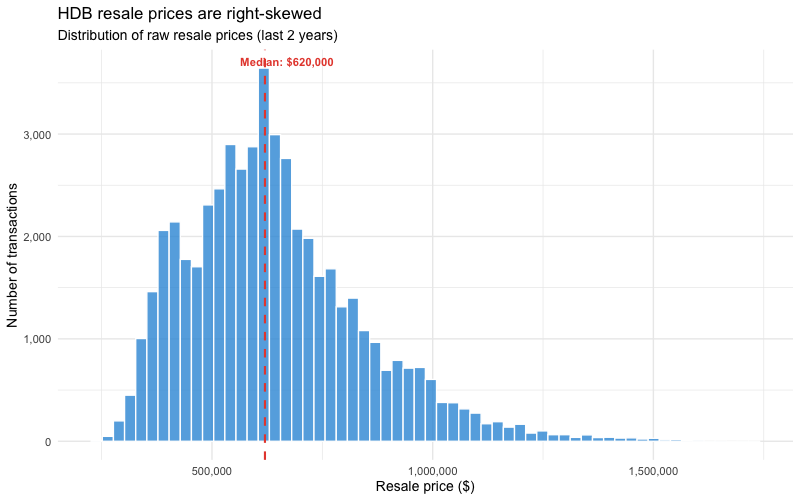

In [7]:
%%R -w 800 -h 500

median_price <- median(df$resale_price)

ggplot(df, aes(x = resale_price)) +
  geom_histogram(bins = 60, fill = '#3498db', color = 'white', alpha = 0.8) +
  geom_vline(xintercept = median_price, color = '#e74c3c', linetype = 'dashed', linewidth = 1) +
  annotate('text', x = median_price + 50000, y = Inf, vjust = 2,
           label = paste0('Median: $', comma(median_price)),
           color = '#e74c3c', fontface = 'bold', size = 4) +
  scale_x_continuous(labels = comma) +
  scale_y_continuous(labels = comma) +
  labs(title = 'HDB resale prices are right-skewed',
       subtitle = 'Distribution of raw resale prices (last 2 years)',
       x = 'Resale price ($)',
       y = 'Number of transactions') +
  theme_minimal(base_size = 14)

## Histogram of log_resale_price

Log10 makes it more symmetric. Keeping the column for EDA but using raw dollars as Y — the coefficients read better in a story.

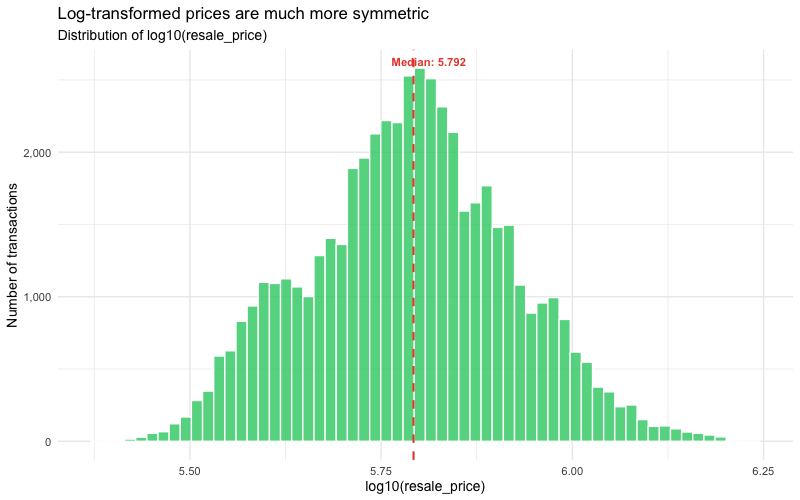

In [8]:
%%R -w 800 -h 500

median_log <- median(df$log_resale_price)

ggplot(df, aes(x = log_resale_price)) +
  geom_histogram(bins = 60, fill = '#2ecc71', color = 'white', alpha = 0.8) +
  geom_vline(xintercept = median_log, color = '#e74c3c', linetype = 'dashed', linewidth = 1) +
  annotate('text', x = median_log + 0.02, y = Inf, vjust = 2,
           label = paste0('Median: ', round(median_log, 3)),
           color = '#e74c3c', fontface = 'bold', size = 4) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Log-transformed prices are much more symmetric',
       subtitle = 'Distribution of log10(resale_price)',
       x = 'log10(resale_price)',
       y = 'Number of transactions') +
  theme_minimal(base_size = 14)

## Boxplot of resale_price by town

Towns reordered by median price. Central Area and Bukit Timah at the top; Woodlands and Jurong West at the bottom.

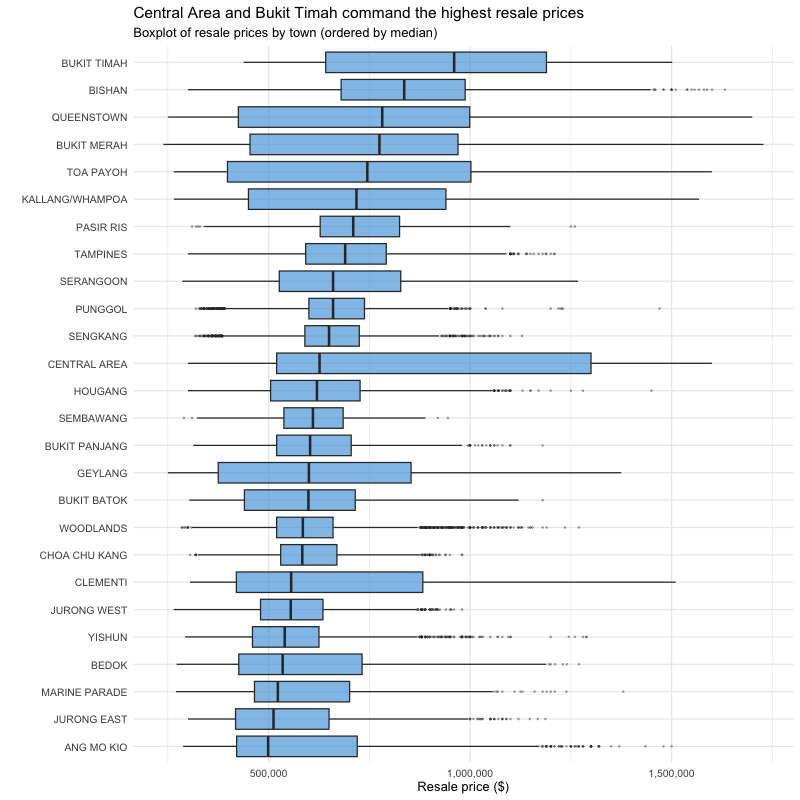

In [9]:
%%R -w 800 -h 800

ggplot(df, aes(x = reorder(town, resale_price, FUN = median), y = resale_price)) +
  geom_boxplot(fill = '#3498db', alpha = 0.6, outlier.size = 0.5, outlier.alpha = 0.3) +
  scale_y_continuous(labels = comma) +
  coord_flip() +
  labs(title = 'Central Area and Bukit Timah command the highest resale prices',
       subtitle = 'Boxplot of resale prices by town (ordered by median)',
       x = '',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 13)

## Boxplot of resale_price by flat_type

Bigger flats cost more, unsurprisingly. But the spread within each type is wide — location and lease do a lot of work too.

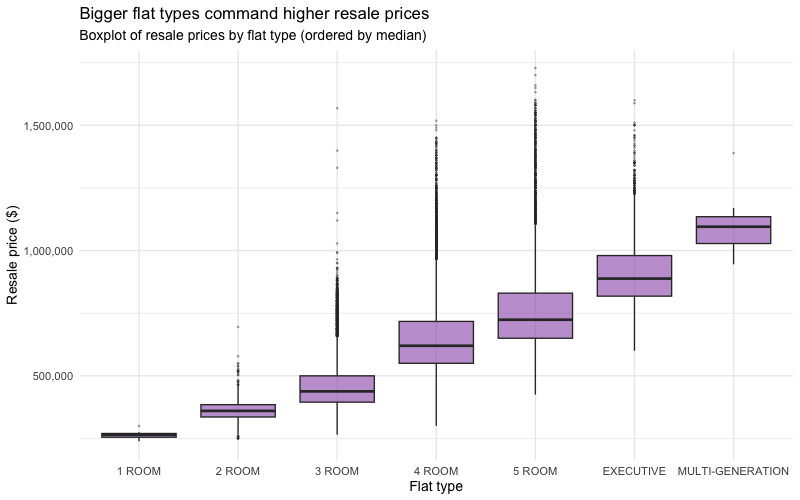

In [10]:
%%R -w 800 -h 500

ggplot(df, aes(x = reorder(flat_type, resale_price, FUN = median), y = resale_price)) +
  geom_boxplot(fill = '#9b59b6', alpha = 0.6, outlier.size = 0.5, outlier.alpha = 0.3) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Bigger flat types command higher resale prices',
       subtitle = 'Boxplot of resale prices by flat type (ordered by median)',
       x = 'Flat type',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 14)

## Scatter — storey_mid vs resale_price

Clear positive relationship. Higher floors, higher prices.

`geom_smooth()` using formula = 'y ~ x'


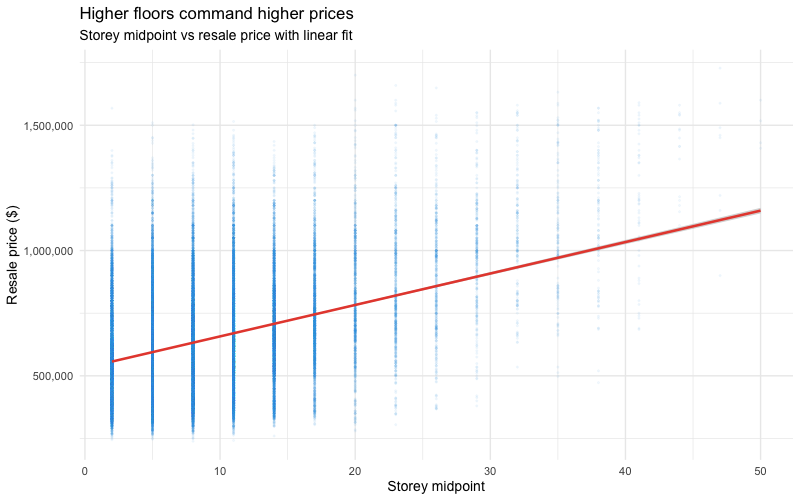

In [11]:
%%R -w 800 -h 500

ggplot(df, aes(x = storey_mid, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, color = '#3498db') +
  geom_smooth(method = 'lm', color = '#e74c3c', linewidth = 1.2, se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Higher floors command higher prices',
       subtitle = 'Storey midpoint vs resale price with linear fit',
       x = 'Storey midpoint',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 14)

## Scatter — remaining_lease_years vs resale_price

LOESS smooth to check whether the lease-price relationship is linear or curves. Watch for steeper drops below ~60 years.

`geom_smooth()` using formula = 'y ~ x'


R callback write-console: In addition:   


R callback write-console: Warning message:
  


R callback write-console: Failed to fit group -1.
Caused by error in `predLoess()`:
! workspace required (4017339597) is too large probably because of setting 'se = TRUE'. 
  


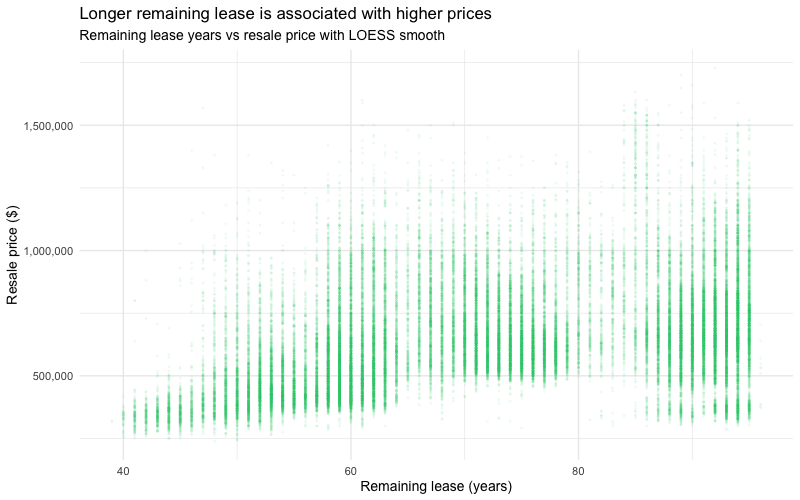

In [12]:
%%R -w 800 -h 500

ggplot(df, aes(x = remaining_lease_years, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, color = '#2ecc71') +
  geom_smooth(method = 'loess', color = '#e74c3c', linewidth = 1.2, se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Longer remaining lease is associated with higher prices',
       subtitle = 'Remaining lease years vs resale price with LOESS smooth',
       x = 'Remaining lease (years)',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 14)

## Scatter — floor_area_sqm vs resale_price

Probably the strongest single predictor. The vertical bands reflect discrete flat types.

`geom_smooth()` using formula = 'y ~ x'


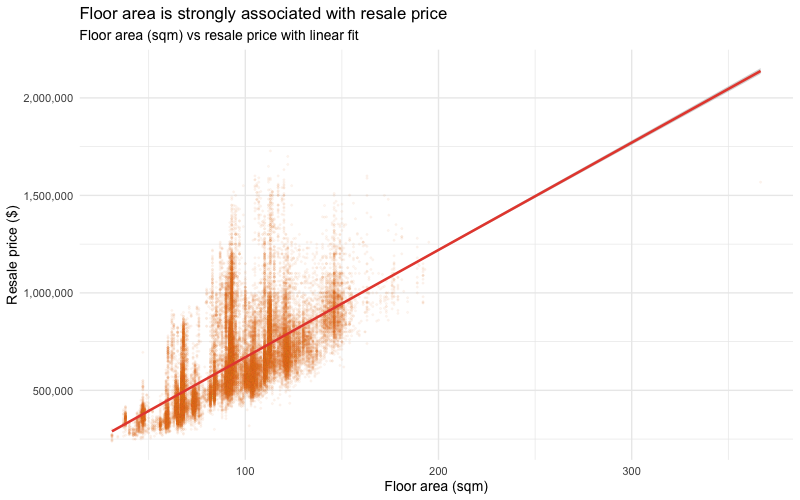

In [13]:
%%R -w 800 -h 500

ggplot(df, aes(x = floor_area_sqm, y = resale_price)) +
  geom_point(alpha = 0.05, size = 0.5, color = '#e67e22') +
  geom_smooth(method = 'lm', color = '#e74c3c', linewidth = 1.2, se = TRUE) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Floor area is strongly associated with resale price',
       subtitle = 'Floor area (sqm) vs resale price with linear fit',
       x = 'Floor area (sqm)',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 14)

## Bar chart of last_digit counts

Horizontal line = expected if digits were uniform (10% each). Look for 0 and 8.

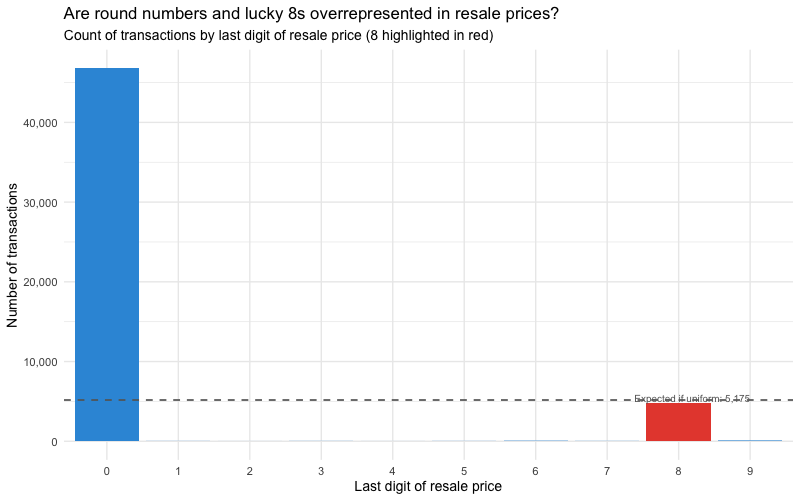

In [14]:
%%R -w 800 -h 500

digit_df <- df %>% count(last_digit)
expected_n <- nrow(df) / 10

ggplot(digit_df, aes(x = factor(last_digit), y = n)) +
  geom_col(aes(fill = last_digit == 8), show.legend = FALSE) +
  scale_fill_manual(values = c('TRUE' = '#e74c3c', 'FALSE' = '#3498db')) +
  geom_hline(yintercept = expected_n, linetype = 'dashed', color = 'gray40', linewidth = 0.8) +
  annotate('text', x = 10, y = expected_n + 200, label = paste0('Expected if uniform: ', comma(round(expected_n))),
           hjust = 1, color = 'gray40', size = 3.5) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Are round numbers and lucky 8s overrepresented in resale prices?',
       subtitle = 'Count of transactions by last digit of resale price (8 highlighted in red)',
       x = 'Last digit of resale price',
       y = 'Number of transactions') +
  theme_minimal(base_size = 14)

## Boxplot — resale_price for ends_in_8 vs other

Do 8-ending prices sit at a different price level, or is this purely a digit-preference thing?

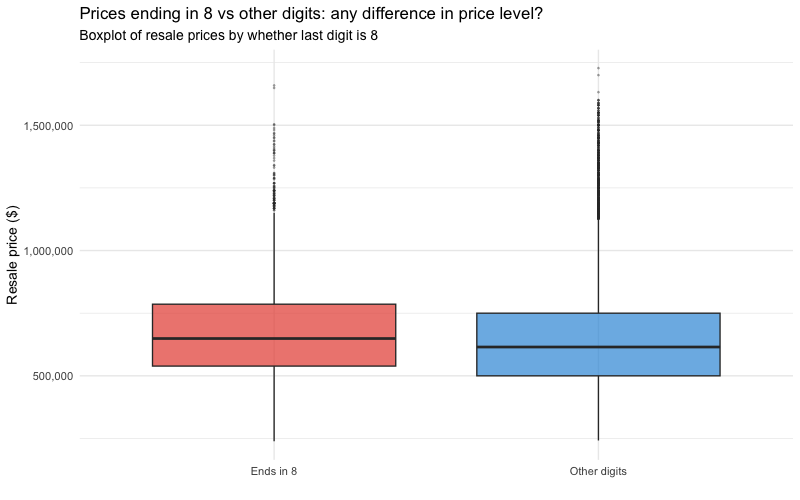

In [15]:
%%R -w 800 -h 500

df$ends_in_8_label <- ifelse(df$ends_in_8 == 1, 'Ends in 8', 'Other digits')

ggplot(df, aes(x = ends_in_8_label, y = resale_price, fill = ends_in_8_label)) +
  geom_boxplot(alpha = 0.7, outlier.size = 0.5, outlier.alpha = 0.3, show.legend = FALSE) +
  scale_fill_manual(values = c('Ends in 8' = '#e74c3c', 'Other digits' = '#3498db')) +
  scale_y_continuous(labels = comma) +
  labs(title = 'Prices ending in 8 vs other digits: any difference in price level?',
       subtitle = 'Boxplot of resale prices by whether last digit is 8',
       x = '',
       y = 'Resale price ($)') +
  theme_minimal(base_size = 14)

## Faceted scatter — storey_mid vs resale_price by top 9 towns

Checking whether the storey premium varies by town or is roughly consistent.

`geom_smooth()` using formula = 'y ~ x'


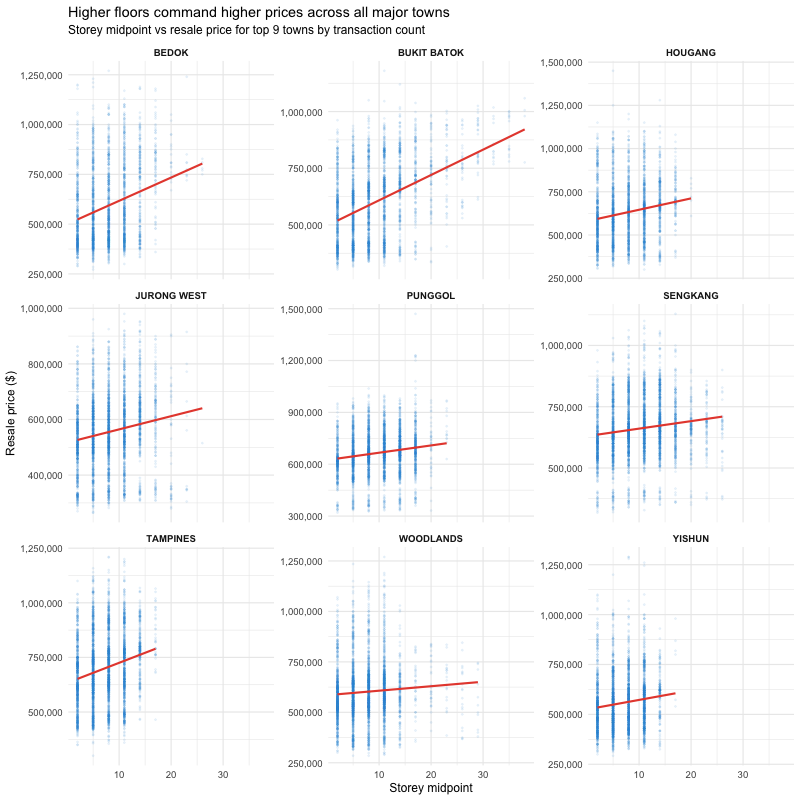

In [16]:
%%R -w 800 -h 800

top9_towns <- df %>% count(town, sort = TRUE) %>% head(9) %>% pull(town)

df %>%
  filter(town %in% top9_towns) %>%
  ggplot(aes(x = storey_mid, y = resale_price)) +
    geom_point(alpha = 0.08, size = 0.5, color = '#3498db') +
    geom_smooth(method = 'lm', color = '#e74c3c', linewidth = 1, se = FALSE) +
    facet_wrap(~ town, ncol = 3, scales = 'free_y') +
    scale_y_continuous(labels = comma) +
    labs(title = 'Higher floors command higher prices across all major towns',
         subtitle = 'Storey midpoint vs resale price for top 9 towns by transaction count',
         x = 'Storey midpoint',
         y = 'Resale price ($)') +
    theme_minimal(base_size = 12) +
    theme(strip.text = element_text(face = 'bold'))

## Key takeaways

- Raw prices are right-skewed but not enough to need log transformation. Using raw `resale_price` as Y with robust SEs.
- Floor area is the dominant predictor — strong linear relationship.
- Higher floors = higher prices, consistent across towns.
- Remaining lease matters, and the LOESS curve suggests non-linearity — worth a quadratic term.
- Town creates huge between-group variation (Central Area 2-3x Woodlands). Need it as a categorical variable.
- Digit preferences are real — 0 and 8 overrepresented. Worth testing in regression.